# Week 1: Data Collection, Text Preprocessing & EDA
## AI-Driven Citizen Grievance & Sentiment Analysis System

**Dataset:** NYC 311 Service Requests  
**Tools:** Python, spaCy, WordCloud, Scikit-learn, Matplotlib  
**Goal:** Clean raw complaint text and perform EDA to understand common civic issues


In [ ]:
# Install required libraries (run once)
# !pip install pandas spacy wordcloud tqdm
# !python -m spacy download en_core_web_sm

import pandas as pd
import re
import string
import spacy
from tqdm import tqdm
from spacy.lang.en.stop_words import STOP_WORDS
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

# Load spaCy English model
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# Load the dataset
df = pd.read_csv("NYC311data.csv")  # adjust filename to yours

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (21635, 53)

Columns: ['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough', 'School Name', 'School Number', 'School Region', 'School Code', 'School Phone Number', 'School Address', 'School City', 'School State', 'School Zip', 'School Not Found', 'School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Garage Lot Name', 'Ferry Direction', 'Ferry Terminal Name', 'Latitude', 'Longitude', 'Locatio

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01-01-16 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01-01-16 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01-01-16 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"


In [ ]:
# Check for nulls and data types
print(df.info())
print("\nNull counts:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21635 entries, 0 to 21634
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      21635 non-null  int64  
 1   Created Date                    21635 non-null  object 
 2   Closed Date                     21505 non-null  object 
 3   Agency                          21635 non-null  object 
 4   Agency Name                     21635 non-null  object 
 5   Complaint Type                  21635 non-null  object 
 6   Descriptor                      21302 non-null  object 
 7   Location Type                   21635 non-null  object 
 8   Incident Zip                    21493 non-null  float64
 9   Incident Address                19185 non-null  object 
 10  Street Name                     19185 non-null  object 
 11  Cross Street 1                  18851 non-null  object 
 12  Cross Street 2                  

## Preprocessing Strategy

We will clean the `Descriptor` column using the following steps:

| Step | Operation | Purpose |
|------|-----------|----------|
| 1 | Lowercase | Normalize text case |
| 2 | Remove URLs & emails | Eliminate noise |
| 3 | Remove special characters & digits | Keep alphabetic text only |
| 4 | Tokenize & remove stopwords | Remove low-value words |
| 5 | Lemmatize tokens | Reduce words to base form |
| 6 | Reconstruct cleaned text | Save as `cleaned_text` column |

In [ ]:
TEXT_COLUMN = "Descriptor"

def clean_text_basic(text):
    """Steps 1-3: fast regex cleaning (no spaCy yet)"""
    if not isinstance(text, str):
        return ""
    text = text.lower()                                   # Step 1: Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)           # Step 2: Remove URLs
    text = re.sub(r"\S+@\S+", "", text)                  # Step 2: Remove emails
    text = re.sub(r"[^a-z\s]", " ", text)                # Step 3: Remove special chars
    text = re.sub(r"\s+", " ", text).strip()             # Step 3: Normalize whitespace
    return text

# Step 1-3: fast regex pass
print("Applying regex cleaning...")
df["temp_text"] = df[TEXT_COLUMN].apply(clean_text_basic)

# Step 4-5: batch lemmatization with progress bar
print("Applying lemmatization (batch mode)...")
cleaned_texts = []

for doc in tqdm(nlp.pipe(df["temp_text"], batch_size=500),
                total=len(df), desc="Lemmatizing"):
    tokens = [
        token.lemma_                    # Step 5: Lemmatize
        for token in doc
        if not token.is_stop            # Step 4: Remove stopwords
        and not token.is_punct
        and len(token.text) > 2
    ]
    cleaned_texts.append(" ".join(tokens))  # FIX: space separator prevents word merging

df["cleaned_text"] = cleaned_texts
df.drop(columns=["temp_text"], inplace=True)

print(f"Done! Cleaned {len(df):,} rows.")
df[["Descriptor", "cleaned_text"]].head(5)

Applying regex cleaning...
Applying lemmatization (batch mode)...


Lemmatizing: 100%|██████████| 21635/21635 [00:08<00:00, 2636.25it/s]

Done! Cleaned 21,635 rows.


,Descriptor,cleaned_text
0,Loud Music/Party,loud music party
1,No Access,access
2,No Access,access
3,Commercial Overnight Parking,commercial overnight parking
4,Blocked Sidewalk,block sidewalk


In [ ]:
# Count empty rows after cleaning (may indicate data issues)
empty_count = df["cleaned_text"].str.strip().eq("").sum()
print(f"Empty rows after cleaning: {empty_count} / {len(df)}")

# Check average token count
df["token_count"] = df["cleaned_text"].apply(lambda x: len(x.split()))
print("\nToken count stats:")
print(df["token_count"].describe())

Empty rows after cleaning: 333 / 21635

Token count stats:
count    21635.000000
mean         2.196487
std          1.013264
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: token_count, dtype: float64


In [ ]:
print(f"Total rows: {len(df)}")

Total rows: 21635


## Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| Lowercase | `str.lower()` | Normalized case |
| URL/email removal | regex | Removed noise |
| Special char removal | `regex [^a-z\s]` | Clean alphabet only |
| Stopword removal | spaCy `is_stop` | ~30–50% token reduction |
| Lemmatization | spaCy `token.lemma_` | Base word forms |

Output: `cleaned_text` column — ready for Word Cloud and N-gram analysis.

In [ ]:
# Use cleaned text for word cloud (not raw Descriptor)
text = " ".join(df["cleaned_text"].dropna().astype(str))

In [ ]:
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    colormap="Blues"
).generate(text)

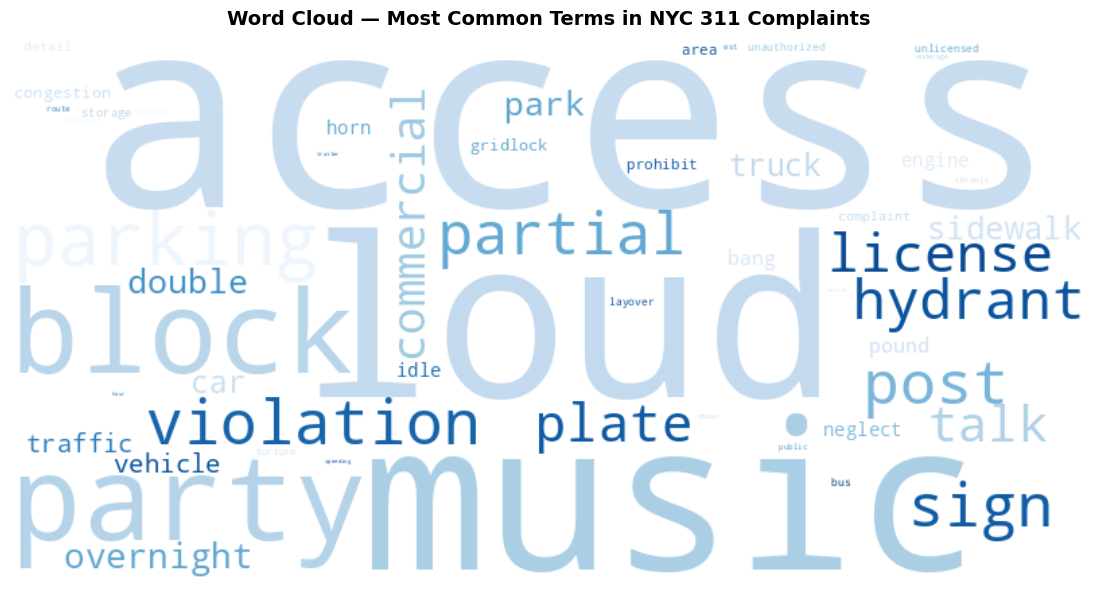

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Most Common Terms in NYC 311 Complaints",
          fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

Word Cloud Analysis

The word cloud visualization highlights the most frequently occurring terms in citizen complaints. Larger words represent higher frequency. From the visualization, common issues such as music parties, loud noise, illegal parking, and access blockage appear frequently, indicating the major concerns reported by citizens.

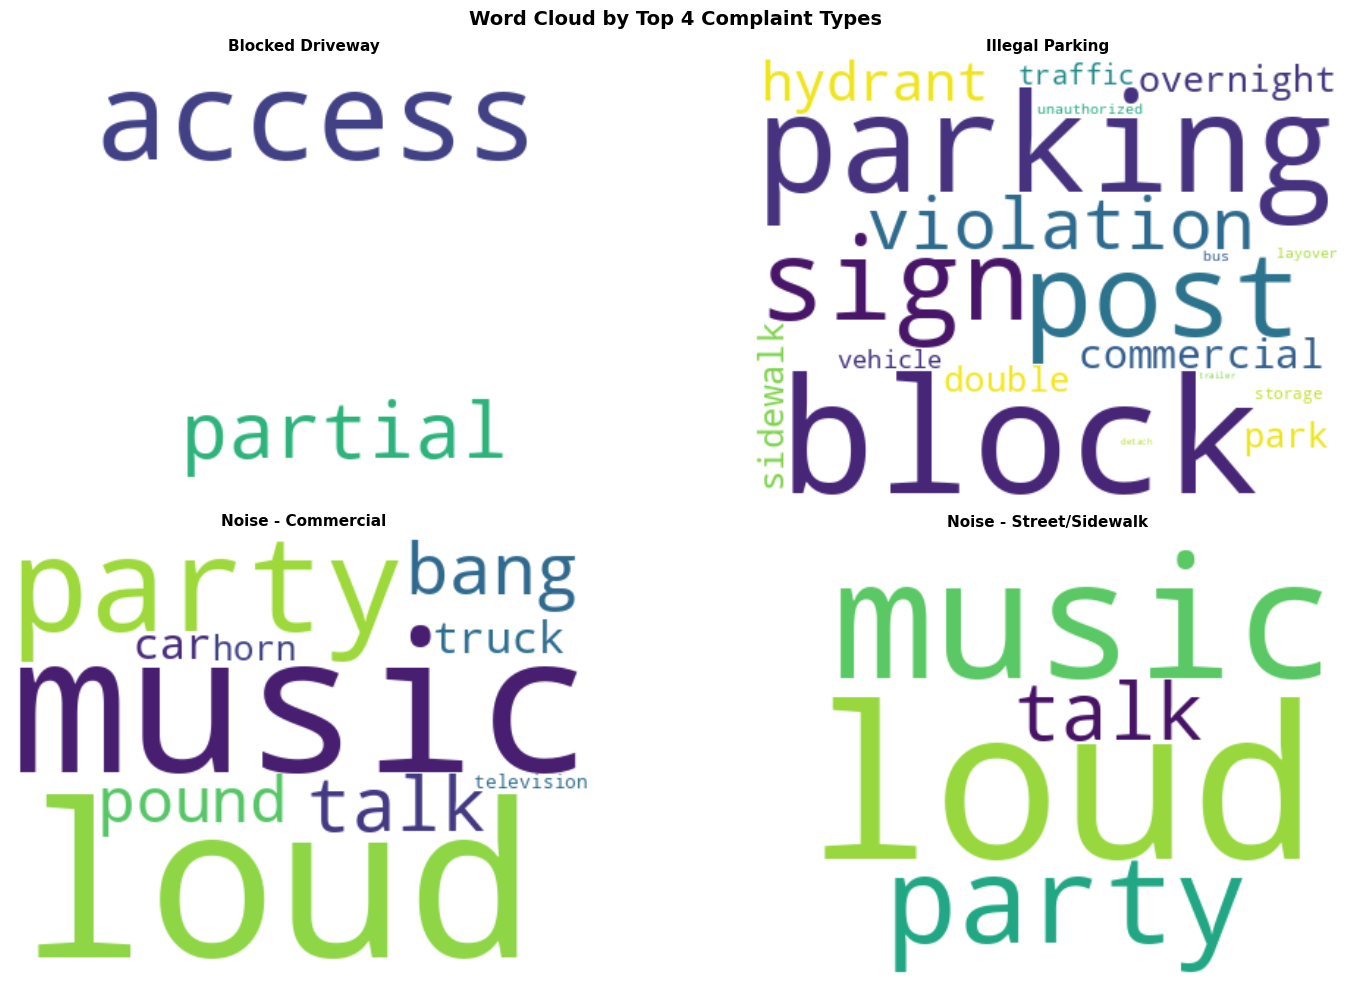

In [ ]:
# Word cloud per complaint type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Word Cloud by Top 4 Complaint Types", fontsize=14, fontweight="bold")
axes = axes.flatten()

top_types = df["Complaint Type"].value_counts().head(4).index

for ax, complaint_type in zip(axes, top_types):
    subset_text = " ".join(
        df[df["Complaint Type"] == complaint_type]["cleaned_text"].dropna()
    )
    wc = WordCloud(width=400, height=300, background_color="white",
                   stopwords=stopwords, collocations=False).generate(subset_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(complaint_type, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
text_data = df["cleaned_text"].dropna()

In [ ]:
##Function to Calculate N-grams
def get_top_ngrams(corpus, ngram_range=(1,1), top_n=20):

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')

    X = vectorizer.fit_transform(corpus)

    sum_words = X.sum(axis=0)

    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vectorizer.vocabulary_.items()]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:top_n]

In [ ]:
##Unigram Frequency (Single Words)
top_unigrams = get_top_ngrams(text_data, (1,1), 20)

unigram_df = pd.DataFrame(top_unigrams, columns=["Word","Frequency"])

unigram_df

,Word,Frequency
0,access,6762
1,loud,4533
2,music,3803
3,party,3332
4,block,3183
5,parking,2663
6,violation,1868
7,post,1795
8,sign,1795
9,partial,1691


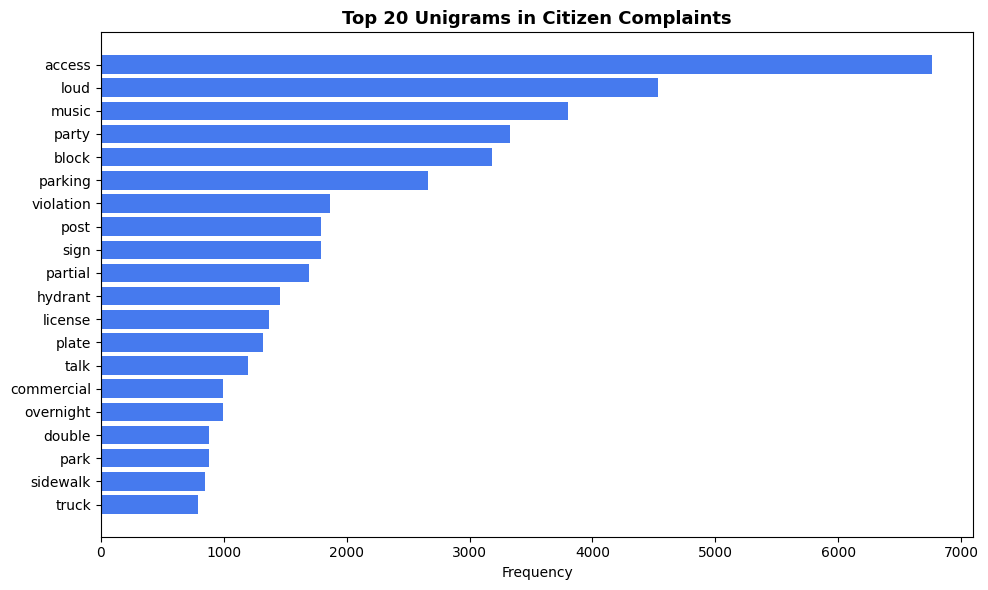

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(unigram_df["Word"], unigram_df["Frequency"], color="#2563EB", alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Top 20 Unigrams in Citizen Complaints", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
##Bigram Frequency (Two Word Phrases)
top_bigrams = get_top_ngrams(text_data, (2,2), 20)

bigram_df = pd.DataFrame(top_bigrams, columns=["Bigram","Frequency"])

bigram_df

,Bigram,Frequency
0,loud music,3332
1,music party,3332
2,post parking,1795
3,parking sign,1795
4,sign violation,1795
5,partial access,1691
6,block hydrant,1459
7,license plate,1323
8,loud talk,1197
9,double park,880


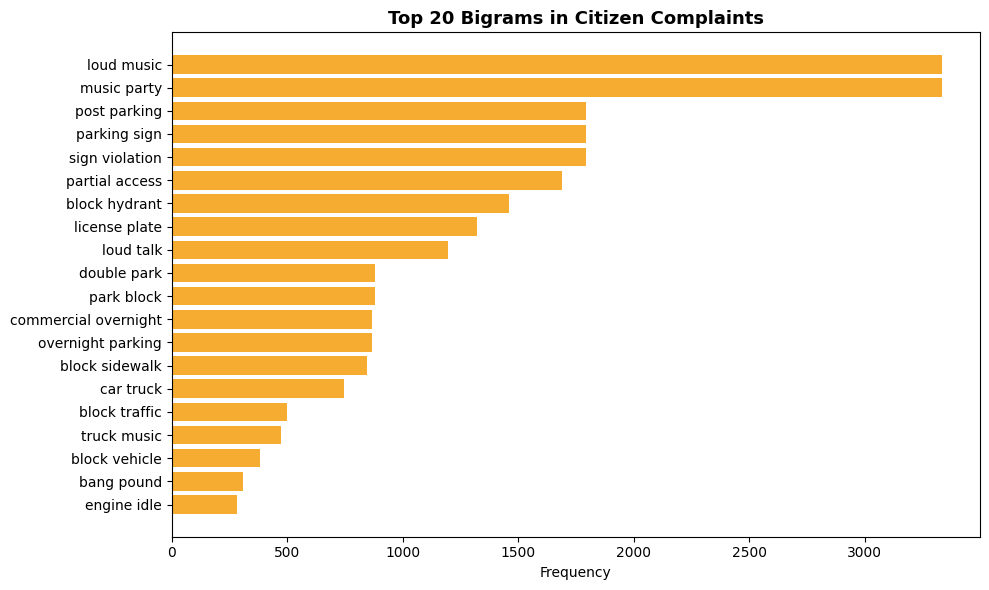

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(bigram_df["Bigram"], bigram_df["Frequency"], color="#F59E0B", alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Top 20 Bigrams in Citizen Complaints", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
##Trigram Frequency (Three Word Phrases)
top_trigrams = get_top_ngrams(text_data, (3,3), 20)

trigram_df = pd.DataFrame(top_trigrams, columns=["Trigram","Frequency"])

trigram_df

,Trigram,Frequency
0,loud music party,3332
1,post parking sign,1795
2,parking sign violation,1795
3,double park block,880
4,commercial overnight parking,868
5,park block traffic,497
6,car truck music,471
7,park block vehicle,383
8,car truck horn,276
9,overnight commercial storage,124


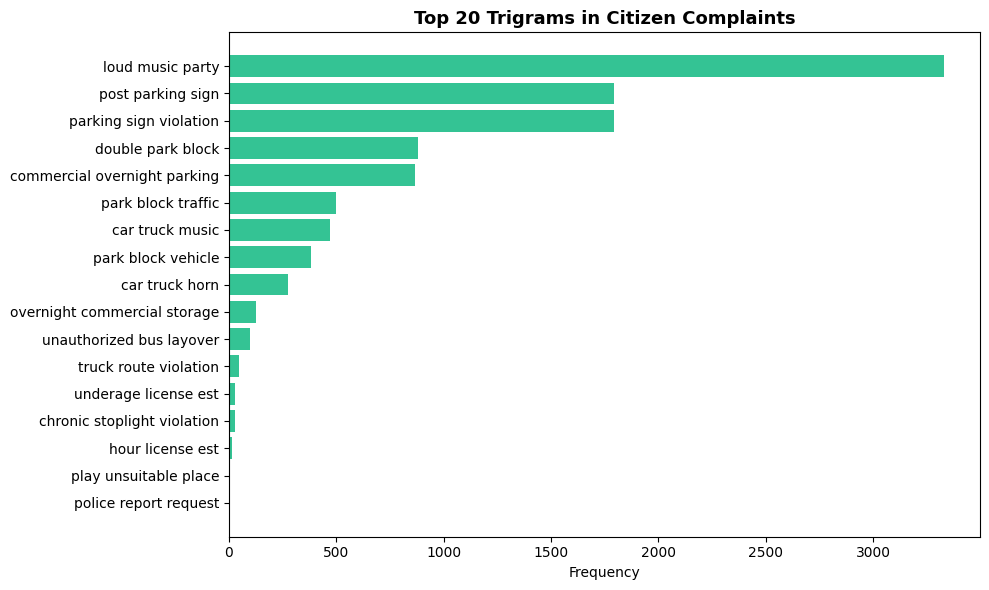

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(trigram_df["Trigram"], trigram_df["Frequency"], color="#10B981", alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Top 20 Trigrams in Citizen Complaints", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

## N-gram Frequency Analysis

N-grams are groups of words used to find the most common words and phrases in citizen complaints.

- **Unigrams** show the most common single words in complaints.
- **Bigrams** show common two-word phrases like *illegal parking* or *loud music*.
- **Trigrams** show three-word phrases that give more context, such as *loud music party*.

This analysis helps understand the main problems reported by citizens, so government departments can identify important issues and respond faster.

# Week 2: Topic Modeling & Department Categorization

## AI-Driven Citizen Grievance & Sentiment Analysis System

**Dataset:** NYC 311 Service Requests  
**Tools:** Python, Scikit-learn, TF-IDF, Logistic Regression, Random Forest  
**Goal:** Convert cleaned text into numerical features using TF-IDF and build a machine learning model to classify complaints into departments.

## TF-IDF Feature Extraction

TF-IDF (Term Frequency - Inverse Document Frequency) converts text data into numerical form so that machine learning models can understand it.

It gives higher importance to important words and reduces the weight of common words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Use cleaned text
X = df["cleaned_text"].dropna()

# Target column (department / complaint type)
y = df["Complaint Type"].loc[X.index]

print("Text samples:", X.shape)
print("Labels:", y.shape)

Text samples: (21635,)
Labels: (21635,)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (21635, 62)


In [ ]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,access,area,bang,block,build,bus,car,chain,chronic,commercial,...,torture,traffic,trailer,truck,unauthorized,underage,unlicensed,unsuitable,vehicle,violation
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.623192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.566438,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import numpy as np

# Average score of each word
scores = np.mean(X_tfidf.toarray(), axis=0)

# Top 20 words
top_indices = scores.argsort()[-20:][::-1]

top_words = [(tfidf.get_feature_names_out()[i], scores[i]) for i in top_indices]

top_words

[('access', np.float64(0.2750686947291751)),
 ('loud', np.float64(0.11403590235158964)),
 ('music', np.float64(0.09818618055375655)),
 ('party', np.float64(0.09360422099517667)),
 ('block', np.float64(0.0784071866470925)),
 ('partial', np.float64(0.066739689165462)),
 ('parking', np.float64(0.056888536858261694)),
 ('hydrant', np.float64(0.052941392263045714)),
 ('talk', np.float64(0.04621510643577869)),
 ('license', np.float64(0.04370840206942303)),
 ('violation', np.float64(0.04347571372819952)),
 ('plate', np.float64(0.043418564141732965)),
 ('post', np.float64(0.042764191243932034)),
 ('sign', np.float64(0.042764191243932034)),
 ('sidewalk', np.float64(0.03214902301794813)),
 ('commercial', np.float64(0.027775115810714186)),
 ('overnight', np.float64(0.027775115810714186)),
 ('truck', np.float64(0.02174741524067442)),
 ('car', np.float64(0.021497641888318562)),
 ('park', np.float64(0.020942070131967805))]

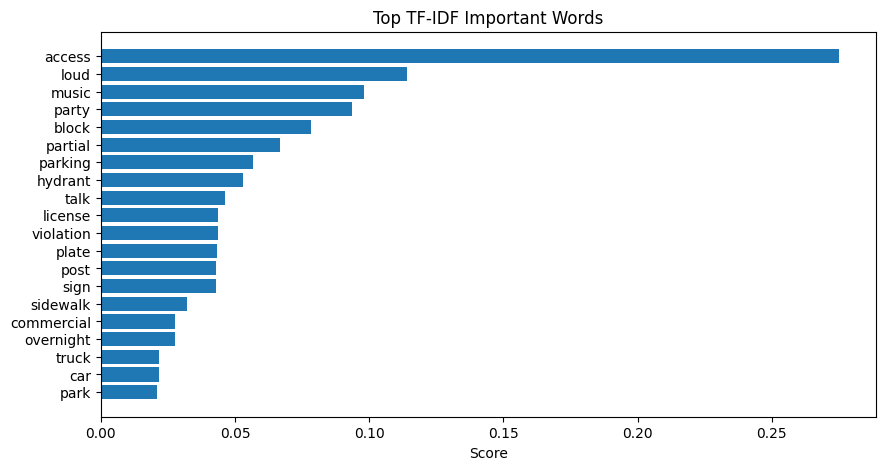

In [ ]:
words = [w[0] for w in top_words]
values = [w[1] for w in top_words]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(words, values)
plt.gca().invert_yaxis()
plt.title("Top TF-IDF Important Words")
plt.xlabel("Score")
plt.show()

## TF-IDF Analysis

TF-IDF helps identify the most important words in citizen complaints.

This representation will be used for training machine learning models for complaint classification.